In [1]:
# Make src/ importable from notebooks/

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RANDOM_STATE, TEST_SIZE
from src.utils import evaluate_model

In [2]:
# MODEL TRAINING & OPTIMIZATION

import pandas as pd
import numpy as np

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Cross Validation
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

# Pipeline
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
# Project Paths (Correct Version)

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent      # Go one folder above notebooks

IMAGE_DIR = PROJECT_ROOT / "images"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"

IMAGE_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Images Folder:", IMAGE_DIR)

Project Root : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML
Images Folder: c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\images


In [4]:
# Project Configuration (Stage 2)

from pathlib import Path
import json

# Root project folder
PROJECT_ROOT = Path.cwd().parent

# Directory paths
IMAGE_DIR = PROJECT_ROOT / "images"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"

# Create directories if they don't exist
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Images :", IMAGE_DIR)
print("Models :", MODEL_DIR)
print("Reports:", REPORT_DIR)

Images : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\images
Models : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\models
Reports: c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\reports


In [5]:
# Load Dataset

df = pd.read_csv("../data/raw/ai4i2020.csv")

# Drop unnecessary columns
df = df.drop(columns=[
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
])

# Feature Engineering
df["Temperature Difference [K]"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

# Features and Target
X = df.drop(columns="Machine failure")
y = df["Machine failure"]

# Train test split
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

In [6]:
# Create Preprocessor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Numerical and categorical columns
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Numerical preprocessing
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[["L", "M", "H"]]))
])

# Column Transformer
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [7]:
# Universal Evaluation Function

def evaluate_model(model, X_test, y_test):
    """
    Evaluate a trained classification model.

    Returns:
        metrics dictionary
        predictions
        prediction probabilities
    """

    # Class prediction
    y_pred = model.predict(X_test)

    # Probability prediction
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

In [8]:
# Baseline Model
"""
The DummyClassifier predicts the majority class (No Failure) for every sample. 
Any ML model must outperform this baseline.
"""
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_pipeline.fit(X_train, y_train)

baseline_metrics, _, _ = evaluate_model(
    baseline_pipeline,
    X_test,
    y_test
)

baseline_metrics


c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Accuracy': 0.966,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1 Score': 0.0,
 'ROC-AUC': 0.5}

In [9]:
# Logistic Regression Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Type','Air temperature [K]','Process temperature [K]',...,'Torque [Nm]', 'Tool wear [min]','Temperature Difference [K]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [10]:
# Decision Tree Pipeline

decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

decision_tree_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Type','Air temperature [K]','Process temperature [K]',...,'Torque [Nm]', 'Tool wear [min]','Temperature Difference [K]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [11]:
# Random Forest Pipeline

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Type','Air temperature [K]','Process temperature [K]',...,'Torque [Nm]', 'Tool wear [min]','Temperature Difference [K]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [12]:
# XGBoost Pipeline

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
    ))
])

xgb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Type','Air temperature [K]','Process temperature [K]',...,'Torque [Nm]', 'Tool wear [min]','Temperature Difference [K]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [13]:
# Compare All Models

models = {
    "Baseline": baseline_pipeline,
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgb_pipeline
}

results = []

for name, model in models.items():

    metrics, _, _ = evaluate_model(model, X_test, y_test)

    metrics["Model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df.set_index("Model")

results_df.round(4)

c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Baseline,0.9660,0.0000,0.0000,0.0000,0.5000
Logistic Regression,0.8205,0.1390,0.8235,0.2378,0.9082
Decision Tree,0.9795,0.7143,0.6618,0.6870,0.8262
Random Forest,0.9865,0.8361,0.7500,0.7907,0.9747
XGBoost,0.9885,0.8947,0.7500,0.8160,0.9847


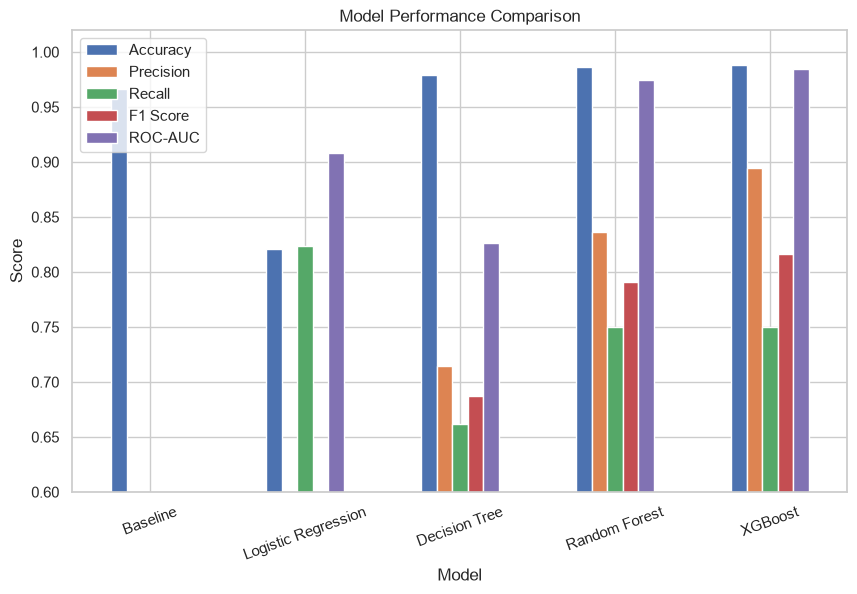

<Figure size 640x480 with 0 Axes>

In [14]:
# Visual Comparison

results_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.xticks(rotation=20)

plt.ylim(0.6,1.02)

plt.show()

plt.savefig(
    IMAGE_DIR / "Model_Performance_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
# Stratified 5-Fold Cross Validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

In [16]:
cv_results = cross_validate(

    random_forest_pipeline,

    X,
    y,

    cv=cv,

    scoring=scoring,

    return_train_score=False

)

cv_summary = pd.DataFrame(cv_results)

cv_summary.mean().round(4)

fit_time          1.8012
score_time        0.1163
test_accuracy     0.9845
test_precision    0.8178
test_recall       0.7052
test_f1           0.7546
test_roc_auc      0.9750
dtype: float64

In [17]:
# Cross Validation Results 

import pandas as pd

# Convert cross_validate output into DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Rename fold columns
cv_results_df.columns = [f"Fold_{i+1}" for i in range(cv_results_df.shape[1])]

# Metric names become a column
cv_results_df.index.name = "Metric"
cv_results_df = cv_results_df.reset_index()

# Calculate Mean and Std across the 5 folds
fold_cols = [col for col in cv_results_df.columns if col.startswith("Fold_")]

cv_results_df["Mean"] = cv_results_df[fold_cols].mean(axis=1)
cv_results_df["Std"] = cv_results_df[fold_cols].std(axis=1)

# Arrange metrics in a logical order
metric_order = [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc",
    "fit_time",
    "score_time",
]

cv_results_df["Metric"] = pd.Categorical(
    cv_results_df["Metric"],
    categories=metric_order,
    ordered=True,
)

cv_results_df = cv_results_df.sort_values("Metric").reset_index(drop=True)

# Save CSV
cv_results_df.to_csv(REPORT_DIR / "cv_results.csv", index=False)

display(cv_results_df)

,Metric,Fold_1,Fold_2,Fold_3,Fold_4,Fold_5,Fold_6,Fold_7,Mean,Std
0,NaN,1.874679,0.118370,0.9880,0.864407,0.761194,0.809524,0.980681,0.913836,0.516814
1,NaN,1.814207,0.115712,0.9855,0.819672,0.735294,0.775194,0.975030,0.888658,0.502009
2,NaN,1.595014,0.112489,0.9860,0.870370,0.691176,0.770492,0.978364,0.857701,0.440736
3,NaN,1.779664,0.123624,0.9815,0.718310,0.750000,0.733813,0.966603,0.864788,0.493643
4,NaN,1.942347,0.111074,0.9815,0.816327,0.588235,0.683761,0.974272,0.871074,0.557696


In [18]:
summary = pd.DataFrame({

    "Metric": scoring,

    "Mean Score": [
        cv_summary["test_accuracy"].mean(),
        cv_summary["test_precision"].mean(),
        cv_summary["test_recall"].mean(),
        cv_summary["test_f1"].mean(),
        cv_summary["test_roc_auc"].mean()
    ],

    "Std Dev": [
        cv_summary["test_accuracy"].std(),
        cv_summary["test_precision"].std(),
        cv_summary["test_recall"].std(),
        cv_summary["test_f1"].std(),
        cv_summary["test_roc_auc"].std()
    ]

})

summary.round(4)

,Metric,Mean Score,Std Dev
0,accuracy,0.9845,0.0029
1,precision,0.8178,0.0609
2,recall,0.7052,0.0706
3,f1,0.7546,0.0478
4,roc_auc,0.9750,0.0054


In [19]:
# Hyperparameter Grid

rf_param_grid = {

    "model__n_estimators": [100,200,300,500],

    "model__max_depth": [5,10,15,None],

    "model__min_samples_split": [2,5,10],

    "model__min_samples_leaf": [1,2,4],

    "model__max_features": ["sqrt","log2"]

}

In [20]:
# Grid Search

rf_grid_search = GridSearchCV(

    estimator=random_forest_pipeline,

    param_grid=rf_param_grid,

    cv=cv,

    scoring="f1",

    n_jobs=-1,

    verbose=1

)

rf_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know 

In [21]:
print("Best Parameters:\n")

print(rf_grid_search.best_params_)

print("\nBest Cross Validation F1:")

print(rf_grid_search.best_score_)

Best Parameters:

{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 500}

Best Cross Validation F1:
0.7380834417642546


In [22]:
rf_grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Type','Air temperature [K]','Process temperature [K]',...,'Torque [Nm]', 'Tool wear [min]','Temperature Difference [K]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

In [23]:
# XGBoost Hyperparameter Grid

xgb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3]
}

In [24]:
print(xgb_pipeline.named_steps)

{'preprocessor': ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]',
                                  'Temperature Difference [K]']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['L',
                                                                   

In [25]:
#xgb parameter grid search

xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.05, 0.1, ...], 'model__max_depth': [3, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more abou

In [26]:
best_model = xgb_grid_search.best_estimator_

print("Best XGBoost Parameters:")
print(xgb_grid_search.best_params_)

print("\nBest CV F1 Score rf:")
print(rf_grid_search.best_score_)

print("\nBest CV F1 Score xgb:")
print(xgb_grid_search.best_score_)

Best XGBoost Parameters:
{'model__colsample_bytree': 1.0, 'model__gamma': 0.3, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best CV F1 Score rf:
0.7380834417642546

Best CV F1 Score xgb:
0.7916987910505748


In [27]:
# Save Best Hyperparameters

best_params = xgb_grid_search.best_params_

print("Best Parameters")
print(best_params)

with open(
    REPORT_DIR / "best_model_config.json",
    "w"
) as f:
    json.dump(best_params, f, indent=4)

print("Saved to reports/best_model_config.json")

Best Parameters
{'model__colsample_bytree': 1.0, 'model__gamma': 0.3, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}
Saved to reports/best_model_config.json


In [28]:
best_metrics, best_pred, best_prob = evaluate_model(
    best_model,
    X_test,
    y_test
)

pd.Series(best_metrics)

Accuracy     0.989000
Precision    0.910714
Recall       0.750000
F1 Score     0.822581
ROC-AUC      0.977667
dtype: float64

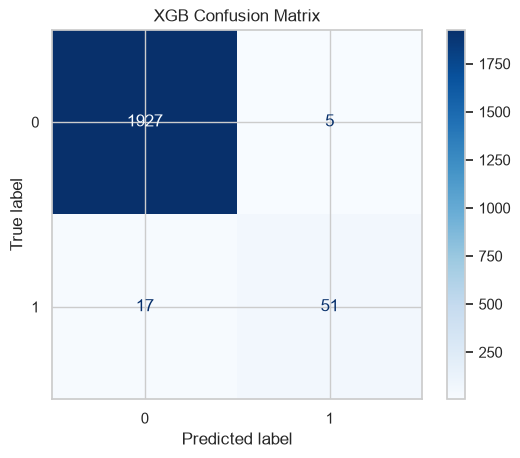

<Figure size 640x480 with 0 Axes>

In [29]:
# Confusion Matrix

ConfusionMatrixDisplay.from_estimator(

    best_model,

    X_test,
    y_test,

    cmap="Blues"

)

plt.title("XGB Confusion Matrix")

plt.show()

plt.savefig(
    IMAGE_DIR / "XGB_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
print(classification_report(
    y_test,
    best_pred
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.75      0.82        68

    accuracy                           0.99      2000
   macro avg       0.95      0.87      0.91      2000
weighted avg       0.99      0.99      0.99      2000



In [31]:
# Save Classification Report

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    best_model.predict(X_test),
    digits=4
)

report_path = REPORT_DIR / "classification_report.txt"

with open(report_path, "w") as f:
    f.write("XGB Classification Report\n")
    f.write("=" * 45)
    f.write("\n\n")
    f.write(report)

print(report)
print(f"\nClassification report saved to: {report_path}")

              precision    recall  f1-score   support

           0     0.9913    0.9974    0.9943      1932
           1     0.9107    0.7500    0.8226        68

    accuracy                         0.9890      2000
   macro avg     0.9510    0.8737    0.9085      2000
weighted avg     0.9885    0.9890    0.9885      2000


Classification report saved to: c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\reports\classification_report.txt


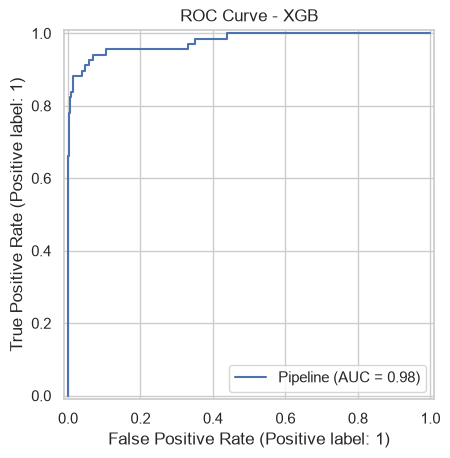

<Figure size 640x480 with 0 Axes>

In [32]:
# ROC Curve

RocCurveDisplay.from_estimator(

    best_model,

    X_test,
    y_test

)

plt.title("ROC Curve - XGB")

plt.show()

plt.savefig(
    IMAGE_DIR / "ROC_Curve_XGB.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

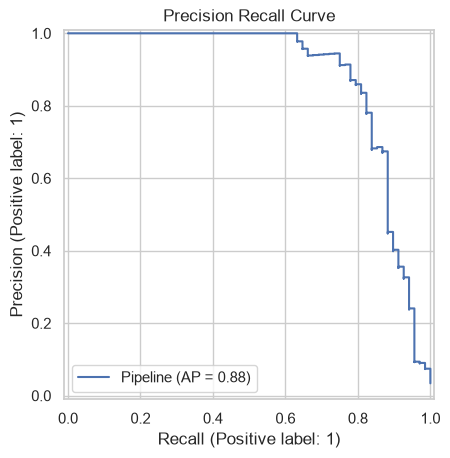

<Figure size 640x480 with 0 Axes>

In [33]:
# Precision Recall Curve

PrecisionRecallDisplay.from_estimator(

    best_model,

    X_test,
    y_test

)

plt.title("Precision Recall Curve")

plt.show()

plt.savefig(
    IMAGE_DIR / "Precision_Recall_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

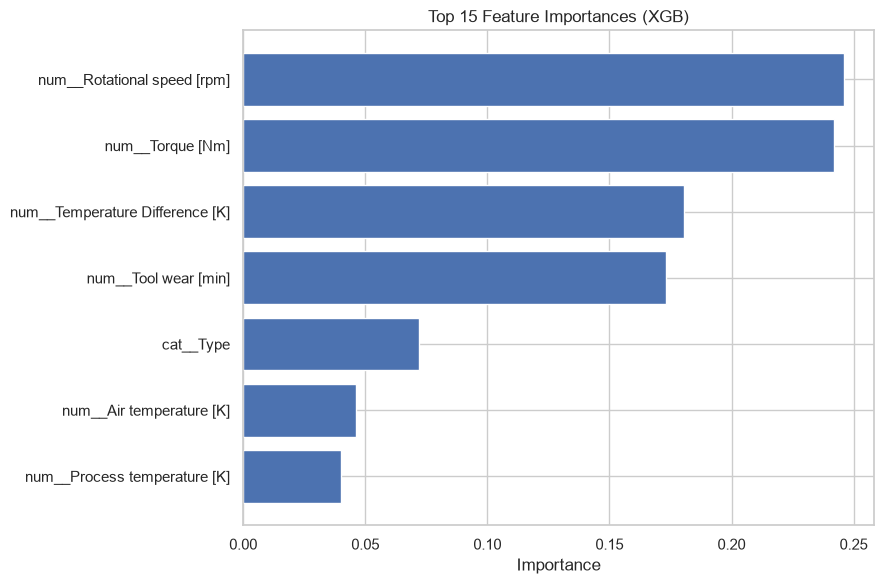

,Feature,Importance
0,num__Rotational speed [rpm],0.246048
1,num__Torque [Nm],0.241808
2,num__Temperature Difference [K],0.180593
3,num__Tool wear [min],0.173319
4,cat__Type,0.071902
5,num__Air temperature [K],0.046213
6,num__Process temperature [K],0.040119


In [34]:
# Feature Importance (Correct Version)

import pandas as pd
import matplotlib.pyplot as plt

# Use fitted preprocessor inside pipeline
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

# Use fitted classifier inside pipeline
xgb_model = best_model.named_steps["model"]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance_df.to_csv(
    REPORT_DIR / "feature_importance.csv",
    index=False
)

plt.figure(figsize=(9,6))

plt.barh(
    importance_df["Feature"][:15][::-1],
    importance_df["Importance"][:15][::-1]
)

plt.title("Top 15 Feature Importances (XGB)")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(importance_df.head(15))

Optimal Threshold : 0.43
Precision         : 0.8983
Recall            : 0.7794
F1 Score          : 0.8346


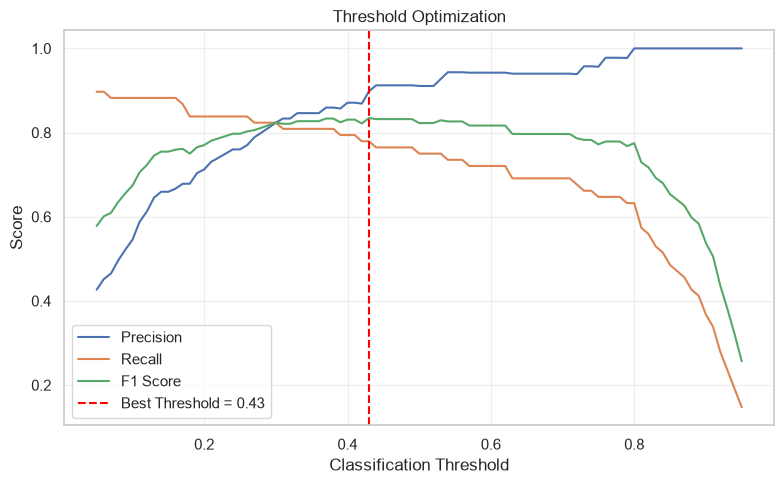

,Threshold,Precision,Recall,F1
0,0.05,0.426573,0.897059,0.578199
1,0.06,0.451852,0.897059,0.600985
2,0.07,0.465116,0.882353,0.609137
3,0.08,0.495868,0.882353,0.634921
4,0.09,0.521739,0.882353,0.655738


In [35]:
# Threshold Optimization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Probability predictions
y_prob = best_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.05,0.96,0.01)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:

    preds = (y_prob >= threshold).astype(int)

    precision_scores.append(
        precision_score(y_test, preds)
    )

    recall_scores.append(
        recall_score(y_test, preds)
    )

    f1_scores.append(
        f1_score(y_test, preds)
    )

# Create dataframe
threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1": f1_scores
})

# Best threshold based on F1
best_idx = threshold_df["F1"].idxmax()

best_threshold = threshold_df.loc[best_idx, "Threshold"]

print("="*50)
print(f"Optimal Threshold : {best_threshold:.2f}")
print(f"Precision         : {threshold_df.loc[best_idx,'Precision']:.4f}")
print(f"Recall            : {threshold_df.loc[best_idx,'Recall']:.4f}")
print(f"F1 Score          : {threshold_df.loc[best_idx,'F1']:.4f}")
print("="*50)

# Save CSV
threshold_df.to_csv(
    REPORT_DIR / "threshold_metrics.csv",
    index=False
)

# Save threshold JSON
with open(MODEL_DIR / "threshold.json","w") as f:
    json.dump(
        {
            "optimal_threshold": float(best_threshold)
        },
        f,
        indent=4
    )

# Plot
plt.figure(figsize=(8,5))

plt.plot(thresholds, precision_scores, label="Precision")
plt.plot(thresholds, recall_scores, label="Recall")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.axvline(
    best_threshold,
    color="red",
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "Threshold_Optimization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(threshold_df.head())

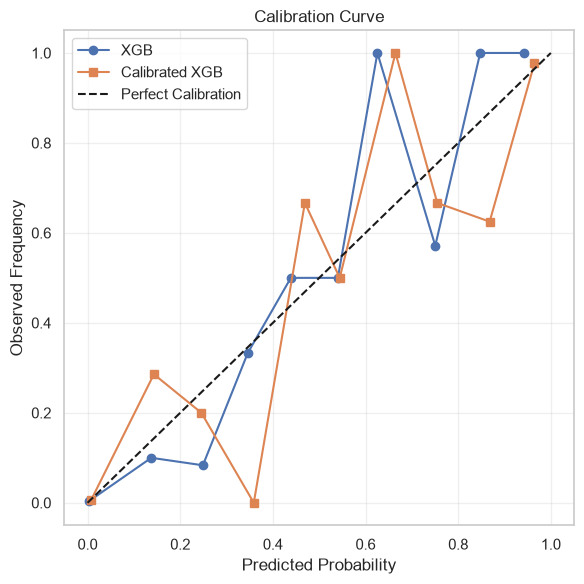

Uncalibrated Brier Score : 0.00915
Calibrated Brier Score   : 0.00933


In [ ]:
# Probability Calibration

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import brier_score_loss

# Calibrate the best CGBoost model using sigmoid
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

# Probability predictions
uncalibrated_prob = best_model.predict_proba(X_test)[:,1]
calibrated_prob = calibrated_model.predict_proba(X_test)[:,1]

# Calibration curve
true_uncal, pred_uncal = calibration_curve(
    y_test,
    uncalibrated_prob,
    n_bins=10
)

true_cal, pred_cal = calibration_curve(
    y_test,
    calibrated_prob,
    n_bins=10
)

# Plot
plt.figure(figsize=(6,6))

plt.plot(
    pred_uncal,
    true_uncal,
    marker="o",
    label="XGB"
)

plt.plot(
    pred_cal,
    true_cal,
    marker="s",
    label="Calibrated XGB"
)

plt.plot([0,1],[0,1],"k--",label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "Calibration_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Brier Scores
uncalibrated_brier = brier_score_loss(y_test, uncalibrated_prob)
calibrated_brier = brier_score_loss(y_test, calibrated_prob)

print(f"Uncalibrated Brier Score : {uncalibrated_brier:.5f}")
print(f"Calibrated Brier Score   : {calibrated_brier:.5f}")

# Save calibration metrics
calibration_results = pd.DataFrame({
    "Model": ["XGB","Calibrated XGB"],
    "Brier Score": [uncalibrated_brier, calibrated_brier]
})

calibration_results.to_csv(
    REPORT_DIR / "calibration_results.csv",
    index=False
)

In [37]:
comparison = pd.DataFrame({

    "Original XGB": pd.Series(
        evaluate_model(xgb_pipeline,X_test,y_test)[0]
    ),

    "Tuned XGB": pd.Series(best_metrics)

})

comparison.round(4)

,Original XGB,Tuned XGB
Accuracy,0.9885,0.9890
Precision,0.8947,0.9107
Recall,0.7500,0.7500
F1 Score,0.8160,0.8226
ROC-AUC,0.9847,0.9777


In [38]:
# Export Model Metrics


REPORT_DIR = Path("../reports")
REPORT_DIR.mkdir(exist_ok=True)

comparison.round(4).to_csv(
    REPORT_DIR / "model_metrics.csv"
)

print("Metrics exported successfully.")

Metrics exported successfully.


In [39]:
# Save Production Pipeline

import joblib

# Save best pipeline
pipeline_path = MODEL_DIR / "xgb_pipeline.pkl"

joblib.dump(best_model, pipeline_path)

# Save feature names
joblib.dump(
    list(preprocessor.get_feature_names_out()),
    MODEL_DIR / "feature_names.pkl"
)

print("="*55)
print("Production pipeline saved successfully!")
print("="*55)
print(f"Pipeline        : {pipeline_path}")
print(f"Feature Names   : {MODEL_DIR/'feature_names.pkl'}")
print(f"Threshold        : {MODEL_DIR/'threshold.json'}")
print("="*55)

Production pipeline saved successfully!
Pipeline        : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\models\xgb_pipeline.pkl
Feature Names   : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\models\feature_names.pkl
Threshold        : c:\Users\UJJAL\OneDrive\Desktop\ML Projects\Predictive-Maintenance-ML\models\threshold.json


# Model Training Summary

## Objective

Train and optimize multiple machine learning models to predict industrial machine failure using the preprocessing pipeline developed in Notebook 02.

## Models Evaluated

* Dummy Classifier (Baseline)
* Logistic Regression
* Decision Tree
* Random Forest
* XGBoost

## Optimization Performed

* Stratified 5-Fold Cross Validation
* GridSearchCV for Random Forest and XGB hyperparameters
* Threshold optimization using prediction probabilities

## Evaluation Metrics

* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC

## Best Model

The XGB model achieved the best balance between precision, recall, F1-score, and ROC-AUC on the test dataset and was saved as the final deployment-ready pipeline.
